In [2]:
# cellpose
from cellpose import io, models, train
import torch
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn

# utils
from tqdm import tqdm
import os
from pathlib import Path
import sys
sys.path.append('../')

# evaluation
from mndino.evaluation import segmentation_report

In [3]:
io.logger_setup() # run this to get printing of progress

2025-12-02 15:41:22,287 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/yren/.cellpose/run.log
2025-12-02 15:41:22,287 [INFO] 
cellpose version: 	4.0.7 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.1+cu128


(<Logger cellpose.io (INFO)>,
 PosixPath('/home/MORGRIDGE/yren/.cellpose/run.log'))

In [13]:
# load image
img_path = Path('/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets') / 'train' / 'images'
mask_path = Path(str(img_path).replace('images', 'mn_masks'))

test_img_path = Path(str(img_path).replace('train', 'test'))
test_mask_path = Path(str(test_img_path).replace('images', 'mn_masks'))
# mask_path = mask_path.with_suffix('.png')

print(img_path)
print(mask_path)

print(test_img_path)
print(test_mask_path)

/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/images
/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/mn_masks
/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/test/images
/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/test/mn_masks


In [14]:
filelist = os.listdir(img_path)
filelist = [file for file in filelist if not file.startswith('.')]

gts_files = os.listdir(mask_path)
gts_files = [file for file in gts_files if not file.startswith('.')]

test_filelist = os.listdir(test_img_path)
test_filelist = [file for file in test_filelist if not file.startswith('.')]

test_gts_files = os.listdir(test_mask_path)
test_gts_files = [file for file in test_gts_files if not file.startswith('.')]

In [18]:
imgs = [io.imread(os.path.join(img_path, f)) for f in filelist]
gts = [io.imread(os.path.join(mask_path, f)) for f in gts_files]

test_imgs = [io.imread(os.path.join(test_img_path, f)) for f in test_filelist]
test_gts = [io.imread(os.path.join(test_mask_path, f)) for f in test_gts_files]

- Generally Recommended Finetuning Setting

In [8]:
model = models.CellposeModel(gpu=True)

2025-12-02 15:43:59,807 [INFO] ** TORCH CUDA version installed and working. **
2025-12-02 15:43:59,809 [INFO] >>>> using GPU (CUDA)
2025-12-02 15:44:01,477 [INFO] >>>> loading model /home/MORGRIDGE/yren/.cellpose/models/cpsam


In [21]:
# Generally Recommended Finetuning Setting
model_path, train_losses, test_losses = train.train_seg(model.net,
                            train_data=imgs, train_labels=gts,
                            test_data=test_imgs, test_labels=test_gts,
                            weight_decay=0.1, learning_rate=1e-5,
                            n_epochs=100, model_name="finetuned_cp4")

2025-12-02 15:48:08,690 [INFO] computing flows for labels


100%|██████████| 121/121 [00:14<00:00,  8.41it/s]

2025-12-02 15:48:23,304 [INFO] computing flows for labels



100%|██████████| 64/64 [00:04<00:00, 14.42it/s]

2025-12-02 15:48:27,833 [INFO] >>> computing diameters



100%|██████████| 64/64 [00:00<00:00, 264.02it/s]

2025-12-02 15:48:28,744 [WARNING] 30 train images with number of masks less than min_train_masks (5), removing from train set
2025-12-02 15:48:28,745 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-12-02 15:48:32,285 [INFO] >>> n_epochs=100, n_train=91, n_test=64
2025-12-02 15:48:32,286 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2025-12-02 15:48:32,288 [INFO] >>> saving model to /scr/yren/micronuclei-detection/baselines/models/finetuned_cp4
2025-12-02 15:48:43,949 [INFO] 0, train_loss=1.8730, test_loss=2.0358, LR=0.000000, time 11.66s
2025-12-02 15:49:29,566 [INFO] 5, train_loss=1.7917, test_loss=1.2750, LR=0.000006, time 57.28s
2025-12-02 15:50:15,289 [INFO] 10, train_loss=0.3216, test_loss=0.0176, LR=0.000010, time 103.00s
2025-12-02 15:51:44,746 [INFO] 20, train_loss=0.0258, test_loss=0.0132, LR=0.000010, time 192.46s
2025-12-02 15:53:14,298 [INFO] 30, train_loss=0.0175, test_loss=0.0127, LR=0.000010, time 282.01s
2025-12-02 15:54:43,692 [INFO] 40, train_loss=0.0153, test_loss=0.0126, LR=0.000010, time 371.40s
2025-12-02 15:56:13,228 [INFO] 50, train_loss=0.0148, test_loss=0.0126, LR=0.000005, time 460.94s
2025-12-02 15:57:42,674 [INFO] 60, train_loss=0

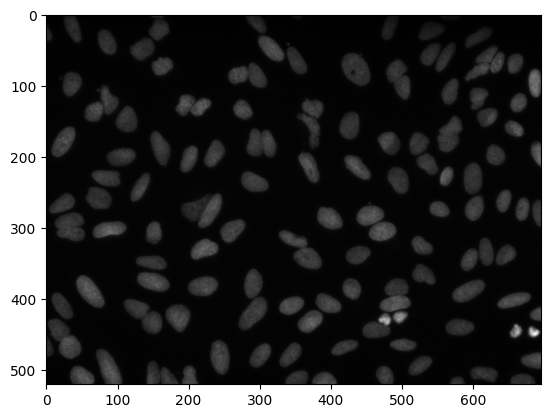

In [31]:
import skimage

test_im = test_imgs[63]
gt_im = test_gts[63]
plt.imshow(test_im, cmap='gray')

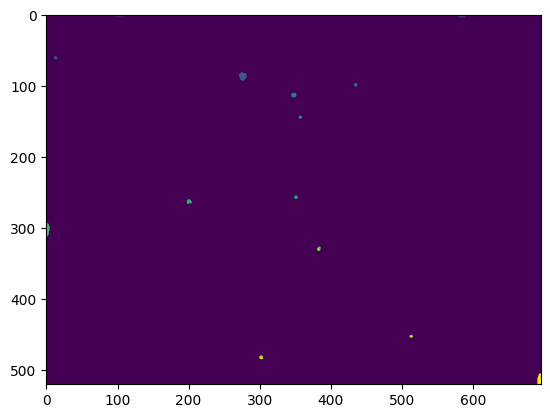

In [34]:
plt.imshow(gt_im)

In [32]:
masks, flows, _ = model.eval(test_im) # styles are a vector of zeros in Cellpose-SAM

2025-12-02 16:08:27,745 [INFO] No cell pixels found.
